# Code you can trust: errors, functions, and one honest check

By now you have copied a block of plotting code more than once. That is normal, and it is also the
moment when repeated code starts producing quietly inconsistent figures. Today you give that
repeated work a name, and you add one check that makes a wrong result fail loudly instead of
looking plausible.

**Minimum viable takeaway:** read the last line of an error message first, write and call one
function, and add one check that would catch a real mistake.

**You do not need to finish the whole notebook.** The core path ends at the **Core checkpoint**
after section 5. Everything after it is **Go further**.

:::{tip} Need an example?
Worked examples, the core task, a solution-shaped hint, and the extension all live in this
notebook. Predict first, try the task, then use the hint at the core checkpoint if you are stuck.
:::

Keep open: the [errors, functions, and checks guide](../notes/functions_and_errors.md).

:::{note} Completed reference
This is `notebooks/05_reliable_code.ipynb` with every TODO answered and every cell run.
Cell order matches the student version, so you can follow along in either.

Written answers are one defensible response, not the only one.
:::


## Learning objectives

By the core checkpoint, you can:

- read a Python traceback from its last line upward and say what failed before changing anything;
- name the three errors you will hit most often this year and the first thing to check for each;
- write a function with inputs, a body, and a return value, and call it more than once;
- replace repeated plotting code with one function call per panel; and
- add one `assert` that catches a wrong unit before it reaches a figure.

In **Go further** you can read the course loader module, use `ValueError` for invalid user input,
write a known-value test, and run the repository `pytest` suite.

## Setup: run this first

This cell finds the project root and loads the Pier record. `load_pier_temperature` is supplied
working code for now — you will open it in **Go further** and see exactly what it does.

If the Pier archive is missing, the cell falls back to a small built-in teaching
example so that today's lesson still works. The printed source line tells you which one you have.
Teaching values are invented; never cite them as observations.

In [1]:
from pathlib import Path
import sys
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebooks", "reference"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), f"Unexpected working directory: {Path.cwd()}"

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from climate_course.pier import (
    EXAMPLE_PIER_NOTE,
    example_pier_frame,
    load_pier_temperature,
)

temperature_files = sorted((PROJECT_ROOT / "data" / "raw" / "pier").glob("LaJolla_TEMP_*.csv"))
if temperature_files:
    pier = load_pier_temperature(temperature_files[-1])
    data_source = temperature_files[-1].name
else:
    pier = example_pier_frame()
    data_source = EXAMPLE_PIER_NOTE

print("Data source:", data_source)
print("Rows and columns:", pier.shape)
print("Date range:", pier["date"].min().date(), "to", pier["date"].max().date())
pier.head()

Data source: LaJolla_TEMP_1916-202603.csv
Rows and columns: (40034, 10)
Date range: 1916-08-22 to 2026-03-31


,YEAR,MONTH,DAY,TIME_PST,TIME_FLAG,SURF_TEMP_C,SURF_FLAG,BOT_TEMP_C,BOT_FLAG,date
0,1916,8,22,NaN,NaN,19.5,0,NaN,NaN,1916-08-22
1,1916,8,23,NaN,NaN,19.9,0,NaN,NaN,1916-08-23
2,1916,8,24,NaN,NaN,19.7,0,NaN,NaN,1916-08-24
3,1916,8,25,NaN,NaN,19.7,0,NaN,NaN,1916-08-25
4,1916,8,26,NaN,NaN,19.5,0,NaN,NaN,1916-08-26


## 1. Worked example: three cells that are almost the same

Read the next cell before running it. It is close to what you get by copying a plotting block
twice and editing it.

**Predict:** what will be different about the two figures, and what will be identical?

/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/439440446.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  recent = pier[pier["date"] >= pier["date"].max() - pd.Timedelta(days=365)]


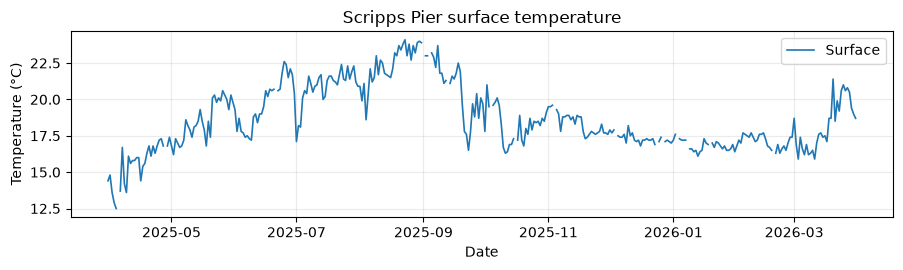

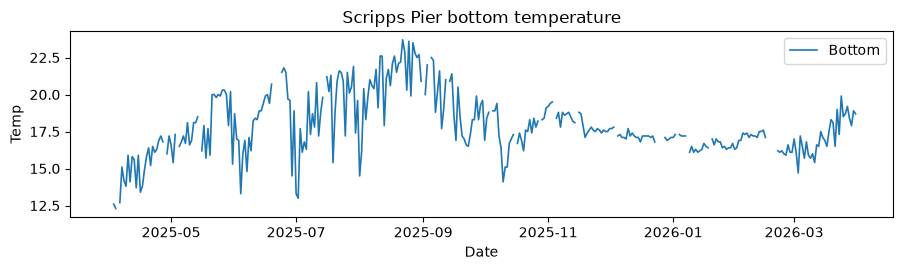

In [2]:
recent = pier[pier["date"] >= pier["date"].max() - pd.Timedelta(days=365)]

# Panel 1 — surface
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(recent["date"], recent["SURF_TEMP_C"], lw=1.2, label="Surface")
ax.set(title="Scripps Pier surface temperature", xlabel="Date", ylabel="Temperature (°C)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

# Panel 2 — bottom
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(recent["date"], recent["BOT_TEMP_C"], lw=1.2, label="Bottom")
ax.set(title="Scripps Pier bottom temperature", xlabel="Date", ylabel="Temp")
ax.legend()
fig.tight_layout()

### Read, then answer

1. How many lines differ between the two blocks? Name each difference.
2. Two differences are *intentional* (the data and the label). The rest are *accidents* of copying.
   Find the accidents.
3. If you now wanted every Pier figure in your final project to have a grid, how many places would
   you have to edit?

**Accidents I found:** the second block drops `ax.grid(alpha=0.25)` entirely, and its y-label is
`"Temp"` instead of `"Temperature (°C)"` — so one panel has a grid and a unit and the other has
neither. Both figures look fine on their own; the inconsistency is only visible side by side, and
neither is *wrong* enough to notice in a thesis. To add a grid to every Pier figure I would have to
edit every copied block: two here, and about a dozen by the end of a real project.

This is the argument for functions. Not elegance — consistency. A copied block drifts, and the
drift is invisible in the figure.


## 2. Errors are evidence, not verdicts

Before writing a function, learn to read what Python says when something goes wrong. A traceback
is a report, and its **last line** is the finding. Everything above it is the chain of calls that
led there — useful second, not first.

Each of the next three cells fails on purpose. They are wrapped so the notebook keeps running;
outside a `try` block Jupyter shows the same text in a red box.

For each one, answer in this order: **What is the error type? What is the last line telling me?
What is the smallest thing I can print to check it?**

### Error 1: `NameError`

In [3]:
try:
    print(suface_temperature)  # noqa: F821 — deliberate typo
except Exception:
    traceback.print_exc()

Traceback (most recent call last):
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/349525863.py", line 2, in <module>
    print(suface_temperature)  # noqa: F821 — deliberate typo
          ^^^^^^^^^^^^^^^^^^
NameError: name 'suface_temperature' is not defined


- Error type: **`NameError`**
- What it means in plain language: **I used a name that Python has never been given.**
  `suface_temperature` is a typo for `surface_temperature`, and even the correct spelling does not
  exist in this notebook. Nothing is broken; the name simply does not exist yet.
- First thing to check: **the spelling, then whether the cell that defines the name actually ran.**
  A cell that has not run shows `[ ]` in the left margin instead of a number. Editing a cell above
  and forgetting to re-run it is the most common cause of this error in a notebook.


### Error 2: `FileNotFoundError`

This is the most common error of the whole week. It is almost never about the file.

In [4]:
try:
    pd.read_csv("data/raw/pier/temperatures.csv")
except Exception:
    traceback.print_exc()

Traceback (most recent call last):
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/985943092.py", line 2, in <module>
    pd.read_csv("data/raw/pier/temperatures.csv")
  File "/Users/holden/opt/anaconda3/envs/climate-data-foundations/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/holden/opt/anaconda3/envs/climate-data-foundations/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/holden/opt/anaconda3/envs/climate-data-foundations/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/holden/opt/anaconda3/envs/climate-data-founda

In [5]:
# The diagnostic, in three prints. Run this before you change any path.
print("Python is currently working in:", Path.cwd())
print("The pier folder exists:", (PROJECT_ROOT / "data" / "raw" / "pier").exists())
print("Files it contains:", [p.name for p in (PROJECT_ROOT / "data" / "raw" / "pier").glob("*")])

Python is currently working in: /Users/holden/Documents/Scripps/Teaching/Climate_science_bootcamp/reference
The pier folder exists: True
Files it contains: ['LaJolla_TEMP_1916-202603.xls', 'LaJolla_SALT_1916-202603.xls', 'bb4003017c_1_1', 'bb4003017c_1_1.zip', 'LaJolla_TEMP_1916-202603.csv', 'LaJolla_SALT_1916-202603.csv']


- Was the path wrong, or was the file genuinely absent? **The path was wrong, in two ways at once.**
  The diagnostic shows the `data/raw/pier` folder exists and lists what is in it, and there is no
  `temperatures.csv` — the real file is `LaJolla_TEMP_1916-202603.csv`. On top of that, the failing
  line used a *relative* path, which only resolves if Python happens to be standing at the project
  root. Building the path from `PROJECT_ROOT` removes that second failure mode entirely.
- A relative path such as `"data/raw/..."` is interpreted from the working directory printed
  above, which is why the same line works in one notebook and fails in another.


### Error 3: `KeyError`

In [6]:
try:
    print(pier["SURFACE_TEMP_C"])
except Exception:
    traceback.print_exc()

Traceback (most recent call last):
  File "/Users/holden/opt/anaconda3/envs/climate-data-foundations/lib/python3.12/site-packages/pandas/core/indexes/base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'SURFACE_TEMP_C'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/3298859390.py", line 2, in <module>
    print(pier["SURFACE_TEMP_C"])
          ~~~~^^^^^^^^^^^^^^^^^^
  File "/Users/holden/o

In [7]:
# The diagnostic: ask the data what it actually contains.
print("Requested: SURFACE_TEMP_C")
print("Available columns:", list(pier.columns))
print("Exact match exists:", "SURFACE_TEMP_C" in pier.columns)

Requested: SURFACE_TEMP_C
Available columns: ['YEAR', 'MONTH', 'DAY', 'TIME_PST', 'TIME_FLAG', 'SURF_TEMP_C', 'SURF_FLAG', 'BOT_TEMP_C', 'BOT_FLAG', 'date']
Exact match exists: False


The provider's column is `SURF_TEMP_C`. A good diagnosis names the symptom *and* the evidence:
"pandas raised `KeyError` because the requested string does not exactly match any column name."

Notice what none of these three errors required: reinstalling anything, restarting the computer, or
rewriting the analysis. Each was answered by one print.

**Pair task:** the person who has typed least so far reads the next traceback aloud, last line
first. Say what failed before either of you touches the code.

## 3. Worked example: the anatomy of a function

A function packages a piece of work under a name so you can run it again without retyping it.

```python
def name_of_function(input_one, input_two):   # header: name and inputs (parameters)
    """One line saying what it does."""       # docstring: what a reader needs to know
    result = input_one + input_two           # body: the work
    return result                            # return: the value handed back to the caller
```

**Predict** the two printed values before running.

In [8]:
def temperature_range(values):
    """Return the difference between the largest and smallest recorded value."""
    observed = pd.Series(values).dropna()
    return observed.max() - observed.min()


print("range of [10, 12, 15]:", temperature_range([10, 12, 15]))
print("range of recent surface temperature (°C):", round(temperature_range(recent["SURF_TEMP_C"]), 2))

range of [10, 12, 15]: 5
range of recent surface temperature (°C): 11.6


Four things to notice, because they are where beginners get stuck:

1. Defining a function runs nothing. `def` only creates the name. The work happens when you
   *call* it with parentheses.
2. `values` is a placeholder. It takes whatever you pass in, and it exists only inside the
   function.
3. Without `return`, a function hands back `None` — a very common cause of "why is my variable
   empty?"
4. The same function worked on a plain list and on a DataFrame column. That reuse is the point.

**Modify and check:** change `temperature_range` so it returns the range rounded to one decimal
place, then call it again on both inputs.

**What changed:** one line — the return becomes
`return round(observed.max() - observed.min(), 1)`. Both printed values gain a fixed single
decimal, and the second `print` no longer needs its own `round(...)` wrapper. Nothing about how the
function is *called* changed, which is the real lesson: the callers did not have to know.


## 4. Core task: turn the repeated plotting code into a function

Now fix section 1. The scaffold below has the function header, docstring, and return statement.
Copy the plotting lines from the **first** panel of section 1 into the body, replacing the
hard-coded pieces with the parameter names.

<Axes: title={'center': 'Scripps Pier surface temperature, most recent year'}, xlabel='Date', ylabel='Temperature (°C)'>

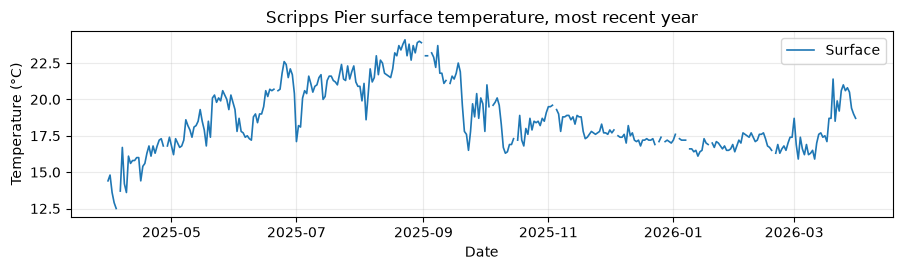

In [9]:
def plot_pier_temperature(dates, values, label, title):
    """Plot one labeled Pier temperature series and return its axes."""
    fig, ax = plt.subplots(figsize=(9, 2.8))

    ax.plot(dates, values, lw=1.2, label=label)
    ax.set(title=title, xlabel="Date", ylabel="Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.25)

    fig.tight_layout()
    return ax


plot_pier_temperature(
    recent["date"],
    recent["SURF_TEMP_C"],
    label="Surface",
    title="Scripps Pier surface temperature, most recent year",
)


### Check before continuing

- Does the figure have a title, both axis labels with a unit, a legend, and a grid?
- Call the function a second time with `recent["BOT_TEMP_C"]` and `label="Bottom"`. Did you have
  to retype any plotting code?
- Change `figsize` to `(9, 2.2)` **inside the function** and rerun both calls. Both panels change
  from one edit. That is the property you were missing in section 1.

<Axes: title={'center': 'Scripps Pier bottom temperature, most recent year'}, xlabel='Date', ylabel='Temperature (°C)'>

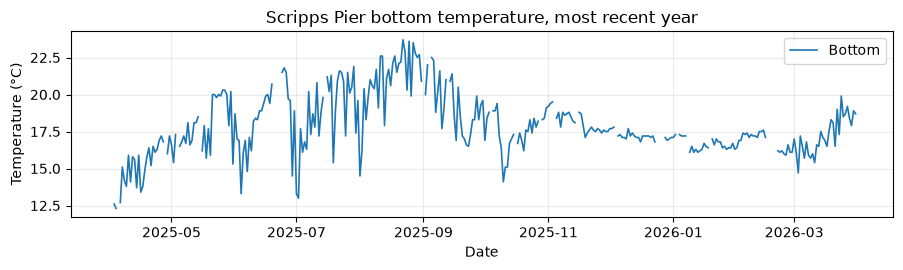

In [10]:
# The second panel is now one call. No plotting code was retyped.
plot_pier_temperature(
    recent["date"],
    recent["BOT_TEMP_C"],
    label="Bottom",
    title="Scripps Pier bottom temperature, most recent year",
)


## 5. One check that fails loudly

A function can also carry an assumption. `assert` states a condition that must be true and stops
with your message when it is not.

Sea-surface temperature at Scripps Pier is somewhere between about −2 °C and 40 °C. Anything
outside that is not an unusual ocean — it is a unit mistake, a fill value, or the wrong column.
The version below refuses to draw such a figure.

<Axes: title={'center': 'Scripps Pier surface temperature, checked'}, xlabel='Date', ylabel='Temperature (°C)'>

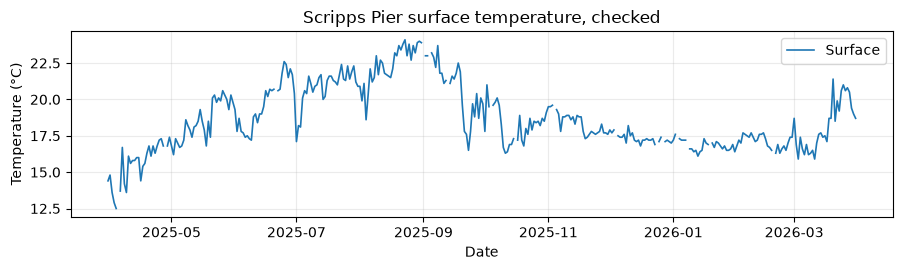

In [11]:
PLAUSIBLE_SST_C = (-2.0, 40.0)


def plot_pier_temperature_checked(dates, values, label, title):
    """Plot one Pier temperature series after checking that the values are plausible °C."""
    observed = pd.Series(values).dropna()
    low, high = PLAUSIBLE_SST_C

    assert len(observed) > 0, f"Nothing to plot for {label}: every value is missing."
    assert observed.between(low, high).all(), (
        f"{label} values fall outside {low} to {high} °C "
        f"(observed {observed.min():.1f} to {observed.max():.1f}). "
        "Check the units before plotting."
    )

    fig, ax = plt.subplots(figsize=(9, 2.8))
    ax.plot(dates, values, lw=1.2, label=label)
    ax.set(title=title, xlabel="Date", ylabel="Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    return ax


plot_pier_temperature_checked(
    recent["date"],
    recent["SURF_TEMP_C"],
    label="Surface",
    title="Scripps Pier surface temperature, checked",
)

### Watch it catch a real mistake

Someone converts to Fahrenheit and forgets to change the axis label. Without the check you get a
clean, well-labeled, completely wrong figure. **Predict what the message will say.**

In [12]:
surface_f = recent["SURF_TEMP_C"] * 9 / 5 + 32

try:
    plot_pier_temperature_checked(
        recent["date"],
        surface_f,
        label="Surface",
        title="Scripps Pier surface temperature",
    )
except AssertionError:
    traceback.print_exc()

Traceback (most recent call last):
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/2287842139.py", line 4, in <module>
    plot_pier_temperature_checked(
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/1966061594.py", line 10, in plot_pier_temperature_checked
    assert observed.between(low, high).all(), (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: Surface values fall outside -2.0 to 40.0 °C (observed 54.5 to 75.4). Check the units before plotting.


A silent wrong answer is worse than a loud failure. The check cost two lines and caught a mistake
that a reviewer would probably not notice on a plot.

What the check does **not** establish: that the sensor was calibrated, that the record is complete,
that flagged values were handled, or that the interpretation is right. A passing check is a
statement about one specific assumption and nothing else.

**Discuss:** name one Pier or MOP assumption you could write as an `assert` in one line.

**My check:** `assert pier["date"].is_monotonic_increasing, "Dates are out of order."` A time series
plotted from unsorted dates produces a scribble that people mistake for noise. For the MOP data:
`assert (mop.waveHs >= 0).all(), "Negative wave height means a fill value, not a small wave."`


## Core checkpoint

Produce three panels — surface, bottom, and their difference — using **only calls** to
`plot_pier_temperature_checked`, then answer the figure questions below.

The difference series is computed for you. Note that it can be near zero or slightly negative, so
it needs its own plausible range; that is a hint about what makes a check honest rather than
decorative.

difference spans -0.20 to 7.20 °C
the -2.0 to 40.0 °C check passed: True
it would also have passed a difference of 25 °C: True


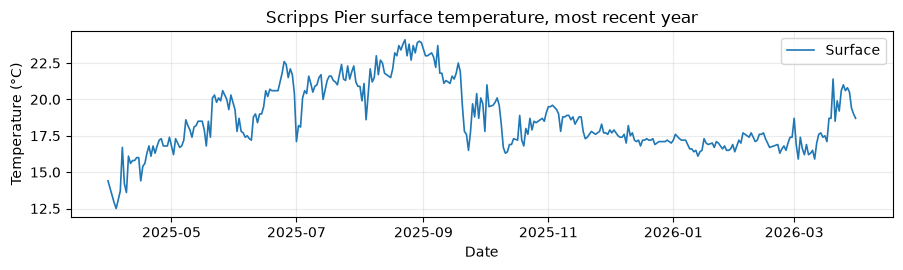

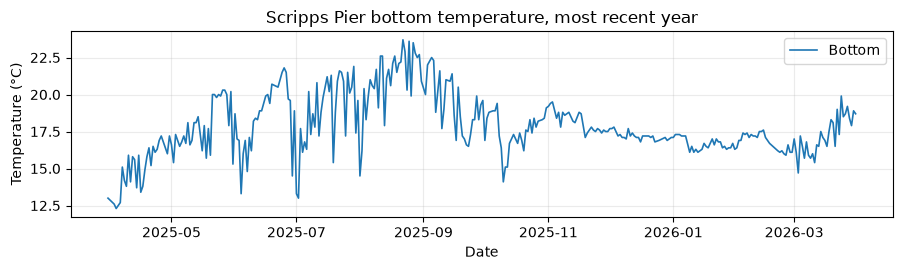

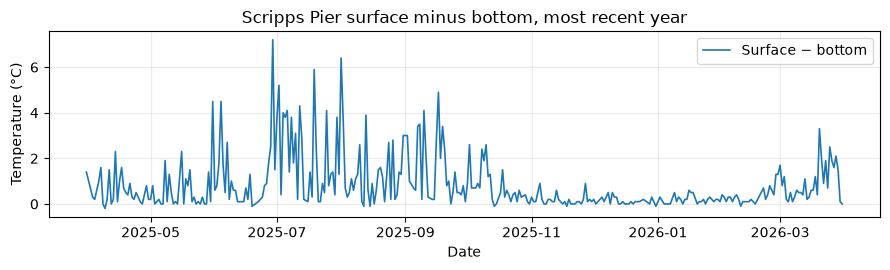

In [13]:
# ---------------------------------------------------------------- BEFORE
# The obvious answer: three calls to the function we already have.

paired = recent.dropna(subset=["SURF_TEMP_C", "BOT_TEMP_C"]).copy()
paired["surface_minus_bottom_c"] = paired["SURF_TEMP_C"] - paired["BOT_TEMP_C"]

plot_pier_temperature_checked(
    paired["date"],
    paired["SURF_TEMP_C"],
    label="Surface",
    title="Scripps Pier surface temperature, most recent year",
)
plot_pier_temperature_checked(
    paired["date"],
    paired["BOT_TEMP_C"],
    label="Bottom",
    title="Scripps Pier bottom temperature, most recent year",
)
plot_pier_temperature_checked(
    paired["date"],
    paired["surface_minus_bottom_c"],
    label="Surface − bottom",
    title="Scripps Pier surface minus bottom, most recent year",
)

# Three panels, no complaints. Now ask what that third check actually tested.
difference = paired["surface_minus_bottom_c"]
low, high = PLAUSIBLE_SST_C
print(f"difference spans {difference.min():.2f} to {difference.max():.2f} °C")
print(f"the {low} to {high} °C check passed: {difference.between(low, high).all()}")
print(f"it would also have passed a difference of 25 °C: {low <= 25 <= high}")


### The third panel passed, and that is the bug

Nothing raised. Three clean figures. But look at the last line printed above: the same check would
have accepted a surface-minus-bottom of **25 °C**, at a pier a few metres deep, in water that never
gets near that spread.

**−2 to 40 °C is a plausible range for a temperature. For a *difference between* two temperatures
it is meaningless.** The third check never had a chance of firing, whatever the data did. It looks
like verification and does nothing — the notebook's own phrase for this is *decorative*.

So: widen `PLAUSIBLE_SST_C`, or write a second function? **A second function.** Widening the
original would also stop it catching the Fahrenheit mistake from section 5, which is the only
reason it exists. A check that covers everything checks nothing.


<Axes: title={'center': 'Scripps Pier surface minus bottom, most recent year'}, xlabel='Date', ylabel='Difference (°C)'>

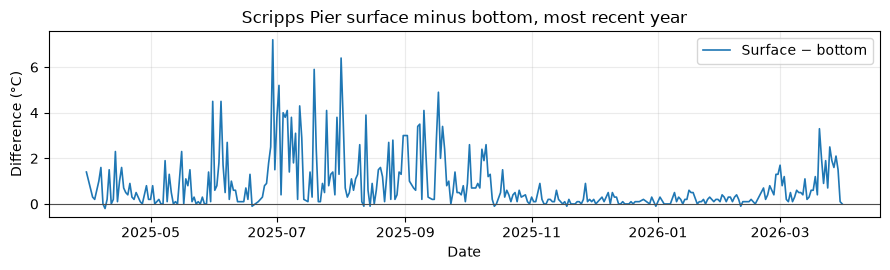

In [14]:
# ---------------------------------------------------------------- AFTER
# A difference gets its own function, with a range that means something for a difference.

PLAUSIBLE_DIFFERENCE_C = (-3.0, 10.0)


def plot_difference_checked(dates, values, label, title):
    """Plot a surface-minus-bottom difference after checking it is a plausible difference."""
    observed = pd.Series(values).dropna()
    low, high = PLAUSIBLE_DIFFERENCE_C

    assert len(observed) > 0, f"Nothing to plot for {label}: every value is missing."
    assert observed.between(low, high).all(), (
        f"{label} values fall outside {low} to {high} °C "
        f"(observed {observed.min():.1f} to {observed.max():.1f}). "
        "A difference that large means these are not the two series you think they are."
    )

    fig, ax = plt.subplots(figsize=(9, 2.8))
    ax.plot(dates, values, lw=1.2, label=label)
    ax.axhline(0, color="0.3", lw=0.8)
    ax.set(title=title, xlabel="Date", ylabel="Difference (°C)")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    return ax


plot_difference_checked(
    paired["date"],
    paired["surface_minus_bottom_c"],
    label="Surface − bottom",
    title="Scripps Pier surface minus bottom, most recent year",
)


Same figure as before. The difference is that this check can now fail — and fail on something the
wide one waves through. Below, the bottom column arrived empty and someone "repaired" it with
`.fillna(0)`, so every difference is really just the surface temperature.


In [15]:
# A mistake that the wide check cannot see: the bottom column came in empty and
# someone "repaired" it with .fillna(0). Every difference is now just the surface
# temperature, which is a perfectly plausible *temperature* and nonsense as a *difference*.
bottom_zero_filled = pd.Series(0.0, index=paired.index)
broken = paired["SURF_TEMP_C"] - bottom_zero_filled

print(f"broken difference spans {broken.min():.1f} to {broken.max():.1f} °C")
print("the wide -2 to 40 °C check accepts it:", broken.between(*PLAUSIBLE_SST_C).all())

try:
    plot_difference_checked(
        paired["date"], broken, label="Surface − bottom", title="Deliberately wrong"
    )
except AssertionError:
    traceback.print_exc()


broken difference spans 12.5 to 24.1 °C
the wide -2 to 40 °C check accepts it: True


Traceback (most recent call last):
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/4237862827.py", line 11, in <module>
    plot_difference_checked(
  File "/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_34196/3339423051.py", line 13, in plot_difference_checked
    assert observed.between(low, high).all(), (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: Surface − bottom values fall outside -3.0 to 10.0 °C (observed 12.5 to 24.1). A difference that large means these are not the two series you think they are.


### Figure check (use this every day)

1. What question does the figure answer? **How surface and bottom temperature at Scripps Pier
   changed over the most recent year, and how far apart they were.**
2. What does each axis represent, including units? **x: date. y: temperature in °C for the first
   two panels, and a temperature *difference* in °C for the third. The units are the same; the
   quantities are not.**
3. What is the one-sentence interpretation? **Surface and bottom track each other closely through
   winter and separate through summer, when the surface warms and the water column stratifies.**
4. What can this figure **not** establish? **Whether the sensors were calibrated, whether missing
   days bias the picture, whether this year is unusual (one year gives no baseline), or anything
   about cause.**

### And the code check

- Which lines exist once now that existed three times in section 1? **Creating the figure and axes,
  the `ax.plot` call, setting the title and both labels, the legend, and the grid — six things that
  were duplicated and could drift apart.**
- Your decision about the difference panel's range, and why: **A second function with its own
  range. Widening the first one to admit differences would stop it catching a Fahrenheit mistake in
  the temperature panels, which is the whole reason it exists.** See the cell below the checkpoint
  for what actually happened when the difference was checked.

:::{dropdown} Stuck? Compare the shape of your solution
A working plotting function should create a figure and axes, plot the two parameters you pass in,
set the title and labels, add a legend and grid, and finally `return ax`. Its essential shape is:

```python
def plot_pier_temperature(dates, values, label, title):
    fig, ax = plt.subplots(figsize=(9, 2.8))
    ax.plot(dates, values, label=label)
    ax.set(title=title, xlabel="Date", ylabel="Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    return ax
```
:::


## Exit ticket

- One mistake today's check would catch: **a Fahrenheit/Celsius mix-up, a fill value such as
  `-999` left in the column, or plotting the wrong column entirely. All three land far outside
  −2 to 40 °C and stop the figure before it is drawn.**
- One scientifically important mistake it would **not** catch: **a sensor reading 2 °C too warm all
  year. Every value stays comfortably inside the range, the figure looks perfect, the check passes,
  and every number derived from it is wrong. A range check tests plausibility, never accuracy.**


---

# Go further

The rest of the notebook is the deeper version of the same ideas. Choose a section; you are not
expected to finish them all.

### A. Default arguments and a real multi-panel figure

Three separate figures are three separate images. Adding an `ax=None` parameter lets the same
function either make its own figure or draw into one you supply.

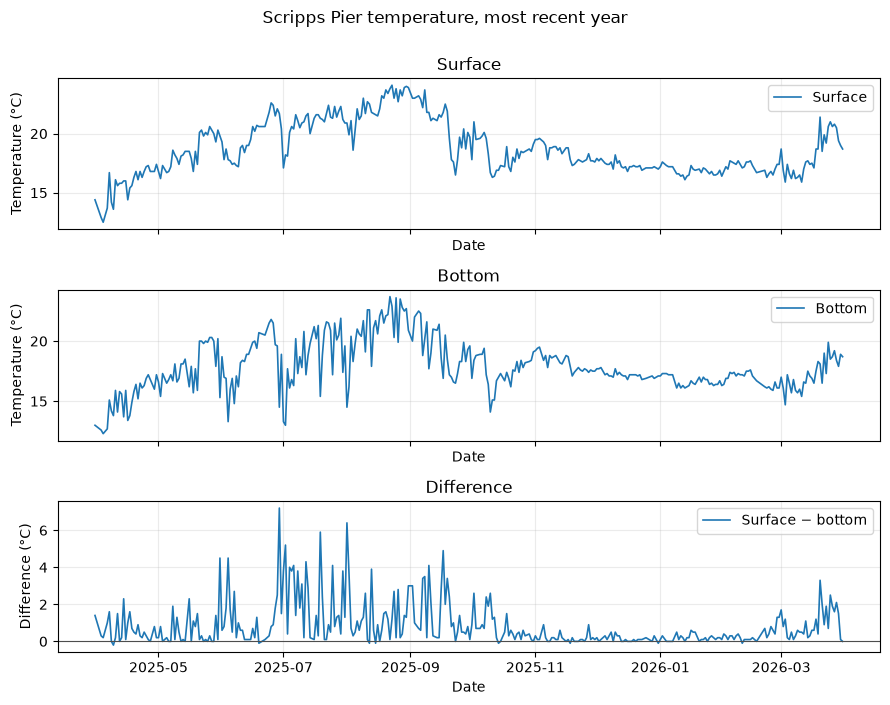

In [16]:
def plot_series(dates, values, label, title, ax=None, ylabel="Temperature (°C)"):
    """Plot one labeled series, creating a figure only when no axes are supplied."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 2.8))
    ax.plot(dates, values, lw=1.2, label=label)
    ax.set(title=title, xlabel="Date", ylabel=ylabel)
    ax.legend()
    ax.grid(alpha=0.25)
    return ax


fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
plot_series(paired["date"], paired["SURF_TEMP_C"], "Surface", "Surface", ax=axes[0])
plot_series(paired["date"], paired["BOT_TEMP_C"], "Bottom", "Bottom", ax=axes[1])
plot_series(
    paired["date"],
    paired["surface_minus_bottom_c"],
    "Surface − bottom",
    "Difference",
    ax=axes[2],
    ylabel="Difference (°C)",
)
axes[2].axhline(0, color="0.3", lw=0.8)
fig.suptitle("Scripps Pier temperature, most recent year", y=1.0)
fig.tight_layout()

`ax=None` is a *default argument*: callers who do not care get sensible behavior, callers who do
get control. Compare the three-panel version with three separate figures and say which better
supports the comparison you actually want to make.

**Which and why:** the three-panel version, because the comparison *is* the point. A shared x-axis
lets you read surface, bottom and difference at the same date without holding anything in your
head. Three separate images force the reader to align three x-axes by eye, which is exactly the
work a figure is supposed to do for them.


### B. Read the loader you have been using

Open `src/climate_course/pier.py` in VS Code. It contains the header discovery, column check, and
date construction that Monday made you do by hand. Find:

- the function's input and what it returns;
- where the header row is discovered, and why it is not hard-coded as line 47;
- where expected columns are checked;
- which failures raise `ValueError` rather than returning something wrong;
- one scientific problem the loader cannot detect.

**Notes:**

- `load_pier_temperature(path)` takes one path and returns a `DataFrame` with the provider's
  columns plus a parsed `date` column.
- `discover_pier_header(path)` searches for the header row instead of hard-coding a line number,
  and raises `ValueError` if it finds no header *or more than one*. A hard-coded row silently
  reads the wrong line the day the provider adds a comment to the top of the file.
- `EXPECTED_PIER_COLUMNS` is checked after loading; anything missing raises
  `ValueError: Missing expected Pier columns: [...]`.
- Failures that raise rather than return: no header, duplicate headers, missing columns, no
  parseable dates, and — in `surface_bottom_difference` — a reversed date window or an empty
  selection. Each one would otherwise hand back an empty or half-right table that summarizes
  cleanly and means nothing.
- One thing it cannot detect: **a sensor that drifted.** The file loads, the columns are present,
  the dates parse, every value is plausible, and the record is wrong. No loader can tell you that.


### C. `assert` versus `ValueError`

`assert` is a check *you* run on your own reasoning. A `ValueError` is how a function tells its
*caller* that the request was invalid. Assertions can be disabled by the interpreter; validation of
user input should not depend on them.

In [17]:
from climate_course.pier import surface_bottom_difference

selection = surface_bottom_difference(
    pier,
    str(pier["date"].min().date()),
    str(pier["date"].max().date()),
    good_only=True,
)
print("paired good-flagged rows:", len(selection))
selection.head()

paired good-flagged rows: 33984


,date,SURF_TEMP_C,BOT_TEMP_C,SURF_FLAG,BOT_FLAG,surface_minus_bottom_c
3620,1926-07-21,21.3,21.3,0,0.0,0.0
3621,1926-07-22,21.3,21.3,0,0.0,0.0
3622,1926-07-23,21.6,21.1,0,0.0,0.5
3623,1926-07-24,21.9,20.1,0,0.0,1.8
3624,1926-07-25,21.9,21.5,0,0.0,0.4


In [18]:
try:
    surface_bottom_difference(pier, "2025-06-30", "2025-01-01")
except ValueError as error:
    print("Expected failure:", error)
else:
    raise AssertionError("A reversed window should fail.")

Expected failure: start must be earlier than or equal to end


The reversed window fails immediately with a message naming the problem, instead of silently
returning an empty table that you would later summarize as though it meant something.

### D. A summary function and a known-value test

The strongest test uses an input whose answer you already know by hand.

In [19]:
def summarize_difference(frame):
    """Return count, mean, and sample standard deviation of surface-minus-bottom °C."""
    required = "surface_minus_bottom_c"
    if required not in frame.columns:
        raise ValueError(f"Missing required column: {required}")
    values = frame[required].dropna()
    if len(values) < 2:
        raise ValueError("At least two differences are required.")
    return {
        "count": int(values.count()),
        "mean_c": float(values.mean()),
        "std_c": float(values.std(ddof=1)),
    }


tiny = pd.DataFrame({"surface_minus_bottom_c": [1.0, 2.0, 3.0]})
known = summarize_difference(tiny)
assert known["count"] == 3
assert np.isclose(known["mean_c"], 2.0)
assert np.isclose(known["std_c"], 1.0)
print("Known-value test passed:", known)
print("Real selection:", summarize_difference(selection))

Known-value test passed: {'count': 3, 'mean_c': 2.0, 'std_c': 1.0}
Real selection: {'count': 33984, 'mean_c': 0.6170403719397364, 'std_c': 1.0802243634063977}


Add a `NaN` to `tiny` and decide whether `dropna` is the behavior you intend. Then write a test
that documents the choice, so a future reader learns it from the code rather than guessing.

### E. Run the repository test suite

`tests/test_pier.py` builds a tiny provider-shaped CSV, so it runs without the network or the full
archive. Run it from the VS Code terminal at the course root:

```bash
pytest -q tests/test_pier.py
```

Then open the file and read one test. Passing means those specific examples behaved as expected in
this environment. It does not prove the observations are correct, that a future provider schema
will load, or that any interpretation is sound. A test is an executable claim with a stated
boundary.

### F. Continuation

- Move `plot_pier_temperature_checked` into `src/climate_course/` and import it here and in one
  other notebook; confirm both produce the same figure.
- Add type hints to your function and a `Raises:` line to its docstring.
- Use `pytest.mark.parametrize` to test `surface_bottom_difference` with `good_only=True/False`,
  a missing column, and several date windows.
- Restart the kernel and run the whole notebook. A notebook that only works in the order you
  happened to click is not a reproducible analysis.